# Avance 3. Baseline

Equipo 23: Detección de Fuentes en Imágenes Astronómicas

* David Adrian Guevara Gaspar - A01796618
* Uriel Díaz Villamil - A01422439
* Uriel Alejandro González Rojo A01048131

---------------------------------------------------------

- Genera / valida un dataset binario: **estrella vs galaxia**.
- Construye particiones **train / validation / test**.
- Incluye referencias mínimas contra azar y clase mayoritaria.
- Entrena un baseline interpretable con **Random Forest + características de imagen**.
- Entrena un baseline visual con una **CNN simple en PyTorch**.
- Reporta métricas de calidad: accuracy, balanced accuracy, precision, recall, F1-score, macro F1 y matriz de confusión.
- Analiza posible subajuste / sobreajuste mediante curvas train / validation.
- Guarda artefactos: métricas, reportes, modelo y figuras.

> Nota: Este notebook usa imágenes descargadas desde SkyView / SIMBAD como baseline preliminar.


In [ ]:
# Instalación de dependencias para Google Colab
!pip -q install astroquery astropy scikit-learn tqdm

In [ ]:
# imports
import os
import json
import time
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.visualization import ZScaleInterval
from astroquery.skyview import SkyView
from astroquery.simbad import Simbad

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [ ]:
# config google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Configuración de reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [ ]:
# configuración del experimento

# ajustar paths
PROJECT_DIR = Path("/content/drive/MyDrive/MNA/PI/avance3")

RAW_DIR = PROJECT_DIR / "raw"
DATASET_DIR = PROJECT_DIR / "dataset"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"

for path in [RAW_DIR, DATASET_DIR, ARTIFACTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# clasificación
CLASS_NAMES = ["estrella", "galaxia"]

# máximo de imágenes a descargar por clase
# test rapido -> 50 - 100
# test serio -> 300 - 1000
MAX_IMAGES_PER_CLASS = 200

# params de imágenes descargadas desde SkyView
SURVEY = "DSS2 Red"
IMAGE_SIZE = 128          # size final usado por el modelo
SKYVIEW_PIXELS = 256      # resolution de descarga antes de resize / modelo

CUTOUT_RADIUS_DEG = 0.04  # ratio angular del recorte

# Split
VAL_SIZE = 0.15
TEST_SIZE = 0.15

# Entrenamiento CNN
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
NUM_EPOCHS = 15
PATIENCE = 5

# omitir descargas si ya existen
SKIP_DOWNLOAD_IF_EXISTS = True

config = {
    "project_dir": str(PROJECT_DIR),
    "survey": SURVEY,
    "max_images_per_class": MAX_IMAGES_PER_CLASS,
    "image_size": IMAGE_SIZE,
    "skyview_pixels": SKYVIEW_PIXELS,
    "cutout_radius_deg": CUTOUT_RADIUS_DEG,
    "val_size": VAL_SIZE,
    "test_size": TEST_SIZE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "num_epochs": NUM_EPOCHS,
}

with open(ARTIFACTS_DIR / "experiment_config.json", "w") as f:
    json.dump(config, f, indent=2)

config

{'project_dir': '/content/drive/MyDrive/MNA/PI/avance3',
 'survey': 'DSS2 Red',
 'max_images_per_class': 200,
 'image_size': 128,
 'skyview_pixels': 256,
 'cutout_radius_deg': 0.04,
 'val_size': 0.15,
 'test_size': 0.15,
 'batch_size': 32,
 'learning_rate': 0.001,
 'num_epochs': 15}

## 1. Consulta de objetos en SIMBAD

Este bloque obtiene coordenadas de objetos catalogados como **Star** y **Galaxy** en SIMBAD.

La finalidad no es usar SIMBAD como dataset final del proyecto, sino como una forma rápida de construir un **baseline externo**. La imagen se descarga después con SkyView usando la coordenada del objeto.


In [ ]:
# consulta de las coordenadas desde SIMBAD

Simbad.ROW_LIMIT = 100000

def query_simbad_objects(label, max_rows=10000):
    """Consulta objetos SIMBAD para estrella o galaxia."""
    if label == "galaxia":
        query = f"""
        SELECT TOP {max_rows}
            main_id, ra, dec, otype
        FROM basic
        WHERE otype = 'Galaxy'
          AND ra IS NOT NULL
          AND dec IS NOT NULL
        """
    elif label == "estrella":
        query = f"""
        SELECT TOP {max_rows}
            main_id, ra, dec, otype
        FROM basic
        WHERE otype = 'Star'
          AND ra IS NOT NULL
          AND dec IS NOT NULL
        """
    else:
        raise ValueError(f"Clase no soportada: {label}")

    table = Simbad.query_tap(query)
    if table is None or len(table) == 0:
        raise RuntimeError(f"No se encontraron objetos para {label}. Revisa la consulta SIMBAD.")

    df = table.to_pandas()
    df["label"] = label
    return df

catalog_dfs = []
for label in CLASS_NAMES:
    print(f"Consultando SIMBAD para clase: {label}")
    df = query_simbad_objects(label, max_rows=max(MAX_IMAGES_PER_CLASS * 5, 500))
    print(f"  Registros obtenidos: {len(df)}")
    catalog_dfs.append(df)

simbad_catalog_df = pd.concat(catalog_dfs, ignore_index=True)
simbad_catalog_df.to_csv(ARTIFACTS_DIR / "simbad_catalog_candidates.csv", index=False)
simbad_catalog_df.groupby("label").size()

Consultando SIMBAD para clase: estrella
  Registros obtenidos: 1000
Consultando SIMBAD para clase: galaxia
  Registros obtenidos: 1000


,0
label,
estrella,1000
galaxia,1000


## 2. Descarga de imágenes con SkyView

Para cada objeto se toma su coordenada RA / Dec y se descarga un recorte de `DSS2 Red`.

Se guardan imágenes normalizadas en:

```text
raw/
  estrella/
  galaxia/
```

Cada imagen queda centrada en el objeto consultado

En esta fase todavía no existe split train / val / test


In [ ]:
# funciones de descarga y normalización

zscale = ZScaleInterval()

def normalize_to_uint8(data):
    """Normaliza una imagen FITS/array a uint8 usando ZScale y fallback por percentiles."""
    arr = np.asarray(data, dtype=np.float32)
    finite = np.isfinite(arr)

    if not finite.any():
        return None

    fill_value = np.nanmedian(arr[finite])
    arr = np.nan_to_num(arr, nan=fill_value, posinf=fill_value, neginf=fill_value)

    try:
        vmin, vmax = zscale.get_limits(arr)
    except Exception:
        vmin, vmax = np.percentile(arr, [1, 99])

    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax <= vmin:
        vmin, vmax = np.percentile(arr, [1, 99])

    if vmax <= vmin:
        return None

    arr = np.clip((arr - vmin) / (vmax - vmin), 0, 1)
    return (arr * 255).astype(np.uint8)


def download_cutout_from_skyview(ra_deg, dec_deg, output_path):
    """Descarga un recorte desde SkyView y lo guarda como PNG."""
    coord = SkyCoord(ra=float(ra_deg) * u.deg, dec=float(dec_deg) * u.deg, frame="icrs")

    images = SkyView.get_images(
        position=coord,
        survey=[SURVEY],
        radius=CUTOUT_RADIUS_DEG * u.deg,
        pixels=SKYVIEW_PIXELS,
        sampler="Lanczos3",
    )

    if images is None or len(images) == 0 or len(images[0]) == 0:
        return False

    hdu = images[0][0]
    image_data = hdu.data

    img_uint8 = normalize_to_uint8(image_data)
    if img_uint8 is None:
        return False

    img = Image.fromarray(img_uint8).convert("L")
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE))
    img.save(output_path)
    return True


def build_raw_image_dataset(catalog_df, max_per_class=MAX_IMAGES_PER_CLASS):
    """Descarga imágenes balanceadas por clase desde SkyView."""
    records = []

    for label in CLASS_NAMES:
        label_dir = RAW_DIR / label
        label_dir.mkdir(parents=True, exist_ok=True)

        existing_files = list(label_dir.glob("*.png"))
        if SKIP_DOWNLOAD_IF_EXISTS and len(existing_files) >= max_per_class:
            print(f"{label}: ya existen {len(existing_files)} imágenes. Se omite descarga.")
            for f in existing_files[:max_per_class]:
                records.append({"image_path": str(f), "label": label, "status": "existing"})
            continue

        label_df = catalog_df[catalog_df["label"] == label].sample(frac=1, random_state=SEED).reset_index(drop=True)

        downloaded = len(existing_files)
        print(f"\nDescargando clase {label}. Existentes: {downloaded}. Objetivo: {max_per_class}")

        # Registrar existentes primero
        for f in existing_files:
            records.append({"image_path": str(f), "label": label, "status": "existing"})

        for idx, row in tqdm(label_df.iterrows(), total=len(label_df), desc=f"SkyView {label}"):
            if downloaded >= max_per_class:
                break

            ra = row["ra"]
            dec = row["dec"]
            main_id = str(row["main_id"]).replace("/", "_").replace(" ", "_")
            output_path = label_dir / f"{label}_{downloaded:05d}.png"

            if output_path.exists():
                downloaded += 1
                continue

            try:
                ok = download_cutout_from_skyview(ra, dec, output_path)
                if ok:
                    records.append({
                        "image_path": str(output_path),
                        "label": label,
                        "ra": float(ra),
                        "dec": float(dec),
                        "main_id": main_id,
                        "status": "downloaded",
                    })
                    downloaded += 1
            except Exception as e:
                # Evitamos detener todo el flujo por una imagen fallida.
                continue

            # Pausa ligera para no saturar el servicio.
            time.sleep(0.1)

        print(f"{label}: imágenes disponibles = {downloaded}")

    raw_manifest = pd.DataFrame(records)
    raw_manifest.to_csv(ARTIFACTS_DIR / "raw_images_manifest.csv", index=False)
    return raw_manifest

raw_manifest = build_raw_image_dataset(simbad_catalog_df)
raw_manifest.groupby("label").size()


Descargando clase estrella. Existentes: 0. Objetivo: 200


SkyView estrella:   0%|          | 0/1000 [00:00<?, ?it/s]

estrella: imágenes disponibles = 200

Descargando clase galaxia. Existentes: 0. Objetivo: 200


SkyView galaxia:   0%|          | 0/1000 [00:00<?, ?it/s]

galaxia: imágenes disponibles = 200


,0
label,
estrella,200
galaxia,200


In [ ]:
# validación de balance mínimo del dataset

class_counts = raw_manifest.groupby("label").size().reindex(CLASS_NAMES, fill_value=0)
print(class_counts)

if (class_counts < 2).any():
    raise RuntimeError(
        "Una de las clases tiene menos de 2 imágenes. "
        "Aumenta MAX_IMAGES_PER_CLASS, revisa la conexión o cambia el survey."
    )

# Balanceo simple: mismo número de imágenes por clase
min_count = int(class_counts.min())
balanced_manifest = (
    raw_manifest
    .drop_duplicates(subset=["image_path"])
    .groupby("label", group_keys=False)
    .apply(lambda x: x.sample(n=min_count, random_state=SEED))
    .reset_index(drop=True)
)

balanced_manifest.to_csv(ARTIFACTS_DIR / "balanced_raw_manifest.csv", index=False)
balanced_manifest.groupby("label").size()

label
estrella    200
galaxia     200
dtype: int64


/tmp/ipykernel_16168/2038380427.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min_count, random_state=SEED))


,0
label,
estrella,200
galaxia,200


## 3. Construcción de train / validation / test

Para que el baseline sea evaluable, se crea una partición estratificada:

- `train`: entrenamiento.
- `val`: validación durante entrenamiento.
- `test`: evaluación final no usada para ajustar hiperparámetros.

Esto es indispensable para analizar subajuste / sobreajuste y reportar métricas reales.


In [ ]:
# Split estratificado y copia a estructura ImageFolder

def reset_dir(path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

reset_dir(DATASET_DIR)

# Primer split: train vs temp
train_df, temp_df = train_test_split(
    balanced_manifest,
    test_size=(VAL_SIZE + TEST_SIZE),
    stratify=balanced_manifest["label"],
    random_state=SEED,
)

# Segundo split: val vs test
relative_test_size = TEST_SIZE / (VAL_SIZE + TEST_SIZE)
val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_size,
    stratify=temp_df["label"],
    random_state=SEED,
)

train_df = train_df.copy(); train_df["split"] = "train"
val_df = val_df.copy(); val_df["split"] = "val"
test_df = test_df.copy(); test_df["split"] = "test"

split_manifest = pd.concat([train_df, val_df, test_df], ignore_index=True)

for _, row in split_manifest.iterrows():
    src = Path(row["image_path"])
    dst_dir = DATASET_DIR / row["split"] / row["label"]
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst = dst_dir / src.name
    shutil.copy2(src, dst)

split_manifest.to_csv(ARTIFACTS_DIR / "split_manifest.csv", index=False)

print("Conteo por split y clase:")
display(pd.crosstab(split_manifest["split"], split_manifest["label"]))

print(f"Dataset ImageFolder creado en: {DATASET_DIR}")

Conteo por split y clase:


label,estrella,galaxia
split,,
test,30,30
train,140,140
val,30,30


Dataset ImageFolder creado en: /content/drive/MyDrive/MNA/PI/avance3/dataset


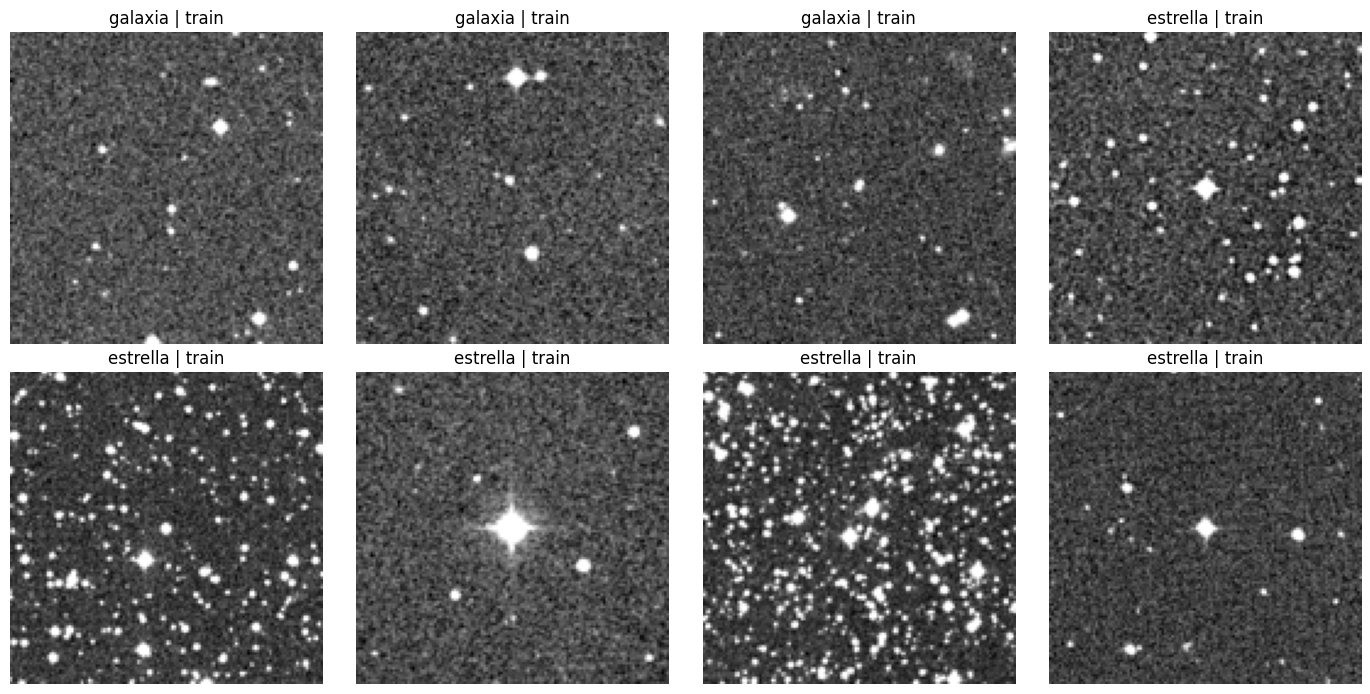

In [ ]:
# sisualización rápida de muestras

def show_samples(split="train", n=8):
    split_df = split_manifest[split_manifest["split"] == split].sample(
        min(n, len(split_manifest[split_manifest["split"] == split])),
        random_state=SEED,
    )

    cols = 4
    rows = int(np.ceil(len(split_df) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(14, 3.5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, split_df.iterrows()):
        img_path = DATASET_DIR / split / row["label"] / Path(row["image_path"]).name
        img = Image.open(img_path)
        ax.imshow(img, cmap="gray")
        ax.set_title(f"{row['label']} | {split}")
        ax.axis("off")

    for ax in axes[len(split_df):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_samples("train", n=8)

## 4. Baseline 0 - clasificadores "dummy"

Antes de entrenar modelos reales, se reportan dos referencias mínimas:

1. **Clase mayoritaria**: siempre predice la clase más frecuente.
2. **Aleatorio estratificado**: predice aleatoriamente respetando la proporción de clases.

Esto permite saber si el modelo realmente aprende o solo supera un umbral


In [ ]:
# Baseline 0 - clasificadores "dummy"

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df["label"])
y_test = label_encoder.transform(test_df["label"])

X_train_dummy = np.zeros((len(y_train), 1))
X_test_dummy = np.zeros((len(y_test), 1))

def evaluate_predictions(y_true, y_pred, name, labels=None):
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    result = {
        "model": name,
        "accuracy": float(acc),
        "balanced_accuracy": float(bal_acc),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1),
    }

    print(f"\n{name}")
    print(json.dumps(result, indent=2))
    print(classification_report(y_true, y_pred, target_names=labels, zero_division=0))
    return result

dummy_results = []

for strategy in ["most_frequent", "stratified"]:
    clf = DummyClassifier(strategy=strategy, random_state=SEED)
    clf.fit(X_train_dummy, y_train)
    y_pred = clf.predict(X_test_dummy)

    dummy_results.append(
        evaluate_predictions(
            y_test,
            y_pred,
            name=f"DummyClassifier_{strategy}",
            labels=label_encoder.classes_,
        )
    )

pd.DataFrame(dummy_results).to_csv(ARTIFACTS_DIR / "dummy_baseline_metrics.csv", index=False)
pd.DataFrame(dummy_results)


DummyClassifier_most_frequent
{
  "model": "DummyClassifier_most_frequent",
  "accuracy": 0.5,
  "balanced_accuracy": 0.5,
  "macro_precision": 0.25,
  "macro_recall": 0.5,
  "macro_f1": 0.3333333333333333
}
              precision    recall  f1-score   support

    estrella       0.50      1.00      0.67        30
     galaxia       0.00      0.00      0.00        30

    accuracy                           0.50        60
   macro avg       0.25      0.50      0.33        60
weighted avg       0.25      0.50      0.33        60


DummyClassifier_stratified
{
  "model": "DummyClassifier_stratified",
  "accuracy": 0.4666666666666667,
  "balanced_accuracy": 0.4666666666666667,
  "macro_precision": 0.46651785714285715,
  "macro_recall": 0.4666666666666667,
  "macro_f1": 0.4660734149054505
}
              precision    recall  f1-score   support

    estrella       0.46      0.43      0.45        30
     galaxia       0.47      0.50      0.48        30

    accuracy                         

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1
0,DummyClassifier_most_frequent,0.500000,0.500000,0.250000,0.500000,0.333333
1,DummyClassifier_stratified,0.466667,0.466667,0.466518,0.466667,0.466073


## 5. Baseline 1 - Random Forest con características simples de imagen

Este baseline responde directamente a la pregunta:

> ¿Se puede determinar la importancia de las características?

Se extraen características globales y morfológicas simples de cada imagen:

- media, desviación estándar, percentiles
- intensidad máxima
- proporción de píxeles brillantes
- concentración central
- asimetría aproximada

No pretende superar necesariamente a una CNN, pero sí dar un modelo interpretable y una referencia de desempeño


In [ ]:
# Feature extraction para baseline clásico

def load_gray_image(path):
    img = Image.open(path).convert("L").resize((IMAGE_SIZE, IMAGE_SIZE))
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr

def extract_image_features(image_path):
    arr = load_gray_image(image_path)
    h, w = arr.shape

    center = arr[h//4:3*h//4, w//4:3*w//4]
    total_sum = arr.sum() + 1e-8
    center_sum = center.sum()

    # Threshold robusto simple para contar píxeles brillantes
    thr = arr.mean() + 2 * arr.std()
    bright_mask = arr > thr

    # Asimetría aproximada: diferencia contra rotación 180 grados
    rotated = np.rot90(arr, 2)
    asymmetry = np.mean(np.abs(arr - rotated))

    features = {
        "mean": float(arr.mean()),
        "std": float(arr.std()),
        "min": float(arr.min()),
        "max": float(arr.max()),
        "p50": float(np.percentile(arr, 50)),
        "p90": float(np.percentile(arr, 90)),
        "p95": float(np.percentile(arr, 95)),
        "p99": float(np.percentile(arr, 99)),
        "bright_fraction": float(bright_mask.mean()),
        "center_mean": float(center.mean()),
        "center_max": float(center.max()),
        "concentration": float(center_sum / total_sum),
        "asymmetry": float(asymmetry),
        "total_intensity": float(total_sum),
    }
    return features

def build_feature_dataframe(df):
    rows = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Extrayendo features"):
        img_path = DATASET_DIR / row["split"] / row["label"] / Path(row["image_path"]).name
        feats = extract_image_features(img_path)
        feats["label"] = row["label"]
        feats["split"] = row["split"]
        feats["image_path"] = str(img_path)
        rows.append(feats)
    return pd.DataFrame(rows)

features_df = build_feature_dataframe(split_manifest)
features_df.to_csv(ARTIFACTS_DIR / "image_features.csv", index=False)

display(features_df.head())
display(pd.crosstab(features_df["split"], features_df["label"]))

Extrayendo features:   0%|          | 0/400 [00:00<?, ?it/s]

,mean,std,min,max,p50,p90,p95,p99,bright_fraction,center_mean,center_max,concentration,asymmetry,total_intensity,label,split,image_path
0,0.374048,0.096966,0.015686,1.0,0.368627,0.470588,0.505882,0.749020,0.019775,0.362782,1.0,0.242471,0.098473,6128.395996,galaxia,train,/content/drive/MyDrive/MNA/PI/avance3/dataset/...
1,0.315723,0.138751,0.031373,1.0,0.294118,0.431373,0.521569,1.000000,0.039185,0.348734,1.0,0.276139,0.121309,5172.808105,estrella,train,/content/drive/MyDrive/MNA/PI/avance3/dataset/...
2,0.366859,0.100172,0.050980,1.0,0.360784,0.470588,0.509804,0.714392,0.022278,0.366104,1.0,0.249485,0.102548,6010.619629,galaxia,train,/content/drive/MyDrive/MNA/PI/avance3/dataset/...
3,0.391889,0.119936,0.105882,1.0,0.372549,0.490196,0.572549,0.996078,0.038879,0.402348,1.0,0.256672,0.113132,6420.709961,estrella,train,/content/drive/MyDrive/MNA/PI/avance3/dataset/...
4,0.336385,0.110873,0.035294,1.0,0.325490,0.443137,0.494118,0.800666,0.027527,0.342887,1.0,0.254833,0.108744,5511.329102,galaxia,train,/content/drive/MyDrive/MNA/PI/avance3/dataset/...


label,estrella,galaxia
split,,
test,30,30
train,140,140
val,30,30



RandomForest_features_val
{
  "model": "RandomForest_features_val",
  "accuracy": 0.7,
  "balanced_accuracy": 0.7,
  "macro_precision": 0.7,
  "macro_recall": 0.7,
  "macro_f1": 0.7
}
              precision    recall  f1-score   support

    estrella       0.70      0.70      0.70        30
     galaxia       0.70      0.70      0.70        30

    accuracy                           0.70        60
   macro avg       0.70      0.70      0.70        60
weighted avg       0.70      0.70      0.70        60


RandomForest_features_test
{
  "model": "RandomForest_features_test",
  "accuracy": 0.7666666666666667,
  "balanced_accuracy": 0.7666666666666666,
  "macro_precision": 0.7777777777777778,
  "macro_recall": 0.7666666666666666,
  "macro_f1": 0.7643097643097643
}
              precision    recall  f1-score   support

    estrella       0.72      0.87      0.79        30
     galaxia       0.83      0.67      0.74        30

    accuracy                           0.77        60
   macro

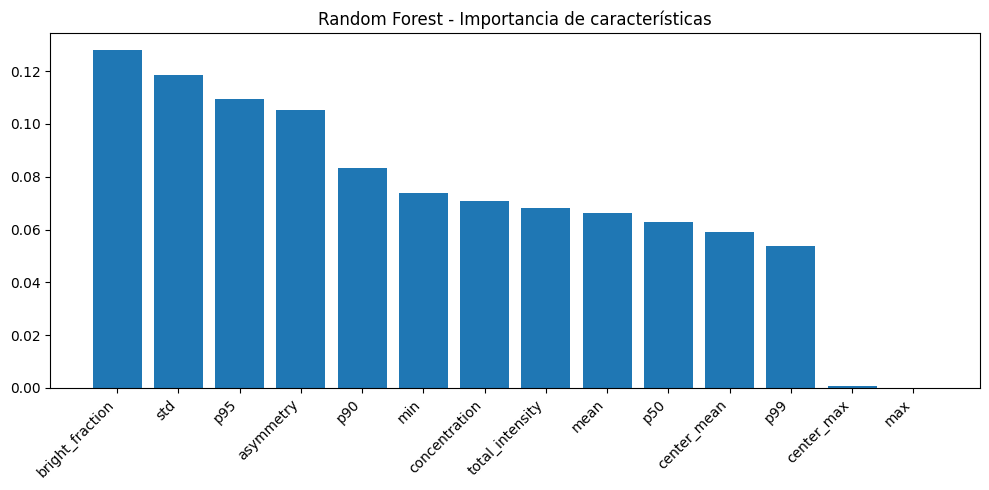

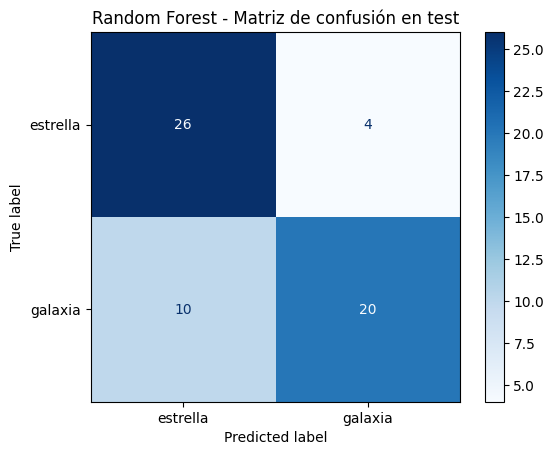

,feature,importance
8,bright_fraction,0.128110
1,std,0.118626
6,p95,0.109540
12,asymmetry,0.105358
5,p90,0.083321
2,min,0.073714
11,concentration,0.070792
13,total_intensity,0.068147
0,mean,0.066262
4,p50,0.062731


In [ ]:
# entrenamiento y evaluación Random Forest

feature_cols = [
    c for c in features_df.columns
    if c not in ["label", "split", "image_path"]
]

train_feat = features_df[features_df["split"] == "train"]
val_feat = features_df[features_df["split"] == "val"]
test_feat = features_df[features_df["split"] == "test"]

X_train = train_feat[feature_cols].values
y_train_rf = label_encoder.transform(train_feat["label"])

X_val = val_feat[feature_cols].values
y_val_rf = label_encoder.transform(val_feat["label"])

X_test = test_feat[feature_cols].values
y_test_rf = label_encoder.transform(test_feat["label"])

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=SEED,
    class_weight="balanced",
    max_depth=None,
    n_jobs=-1,
)

rf.fit(X_train, y_train_rf)

rf_val_pred = rf.predict(X_val)
rf_test_pred = rf.predict(X_test)

rf_val_metrics = evaluate_predictions(
    y_val_rf,
    rf_val_pred,
    name="RandomForest_features_val",
    labels=label_encoder.classes_,
)

rf_test_metrics = evaluate_predictions(
    y_test_rf,
    rf_test_pred,
    name="RandomForest_features_test",
    labels=label_encoder.classes_,
)

# Importancia de características
importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)

importances.to_csv(ARTIFACTS_DIR / "random_forest_feature_importance.csv", index=False)

plt.figure(figsize=(10, 5))
plt.bar(importances["feature"], importances["importance"])
plt.xticks(rotation=45, ha="right")
plt.title("Random Forest - Importancia de características")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "random_forest_feature_importance.png", dpi=160)
plt.show()

# Matriz de confusión RF
cm = confusion_matrix(y_test_rf, rf_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_)
disp.plot(cmap="Blues")
plt.title("Random Forest - Matriz de confusión en test")
plt.savefig(ARTIFACTS_DIR / "random_forest_confusion_matrix.png", dpi=160)
plt.show()

with open(ARTIFACTS_DIR / "random_forest_metrics.json", "w") as f:
    json.dump({"val": rf_val_metrics, "test": rf_test_metrics}, f, indent=2)

importances.head(10)

## 6. Baseline 2 - CNN simple en PyTorch

Este modelo es el baseline visual.
A diferencia del Random Forest, aprende patrones directamente desde los píxeles.

Se usa una arquitectura pequeña para evitar complejidad excesiva:

```text
Conv → BatchNorm → ReLU → MaxPool
Conv → BatchNorm → ReLU → MaxPool
Conv → BatchNorm → ReLU → MaxPool

AdaptiveAvgPool
Dense → Dropout → Dense
```

La capa `AdaptiveAvgPool2d` evita errores de dimensiones si se cambia `IMAGE_SIZE`.


In [ ]:
# DataLoaders PyTorch

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ToTensor(),
    # Normalización simple para imágenes RGB convertidas desde grayscale
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

train_dataset = datasets.ImageFolder(DATASET_DIR / "train", transform=train_transforms)
val_dataset = datasets.ImageFolder(DATASET_DIR / "val", transform=eval_transforms)
test_dataset = datasets.ImageFolder(DATASET_DIR / "test", transform=eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Class to index:", train_dataset.class_to_idx)
print("Train:", len(train_dataset), "Val:", len(val_dataset), "Test:", len(test_dataset))

Class to index: {'estrella': 0, 'galaxia': 1}
Train: 280 Val: 60 Test: 60


In [ ]:
# Definición de CNN simple

class SimpleAstroCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((4, 4)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = SimpleAstroCNN(num_classes=len(train_dataset.classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

model

SimpleAstroCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1024, out_featu

In [ ]:
# funciones de entrenamiento/evaluación

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            if is_train:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    return {
        "loss": float(avg_loss),
        "accuracy": float(acc),
        "balanced_accuracy": float(bal_acc),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1),
        "y_true": all_labels,
        "y_pred": all_preds,
    }

In [ ]:
# Entrenamiento con validación y early stopping

history = []
best_val_f1 = -1.0
best_model_path = ARTIFACTS_DIR / "simple_astro_cnn_best.pt"
epochs_without_improvement = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_metrics = run_epoch(model, train_loader, criterion, optimizer)
    val_metrics = run_epoch(model, val_loader, criterion, optimizer=None)

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train_loss={row['train_loss']:.4f} train_f1={row['train_macro_f1']:.4f} | "
        f"val_loss={row['val_loss']:.4f} val_f1={row['val_macro_f1']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        torch.save(model.state_dict(), best_model_path)
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping activado en epoch {epoch}. Mejor val_macro_f1={best_val_f1:.4f}")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(ARTIFACTS_DIR / "cnn_training_history.csv", index=False)
history_df.tail()

Epoch 01/15 | train_loss=0.6886 train_f1=0.6345 | val_loss=0.7523 val_f1=0.3333
Epoch 02/15 | train_loss=0.5608 train_f1=0.7324 | val_loss=0.6830 val_f1=0.4357
Epoch 03/15 | train_loss=0.5334 train_f1=0.7455 | val_loss=0.6908 val_f1=0.5238
Epoch 04/15 | train_loss=0.5684 train_f1=0.7615 | val_loss=0.5176 val_f1=0.7569
Epoch 05/15 | train_loss=0.5507 train_f1=0.7217 | val_loss=0.4962 val_f1=0.7569
Epoch 06/15 | train_loss=0.5276 train_f1=0.7631 | val_loss=0.4699 val_f1=0.7600
Epoch 07/15 | train_loss=0.5233 train_f1=0.7487 | val_loss=0.4607 val_f1=0.7624
Epoch 08/15 | train_loss=0.5020 train_f1=0.7615 | val_loss=0.4388 val_f1=0.7643
Epoch 09/15 | train_loss=0.5429 train_f1=0.7581 | val_loss=0.4790 val_f1=0.7758
Epoch 10/15 | train_loss=0.5331 train_f1=0.7453 | val_loss=0.4479 val_f1=0.8000
Epoch 11/15 | train_loss=0.5276 train_f1=0.7804 | val_loss=0.4344 val_f1=0.8000
Epoch 12/15 | train_loss=0.4885 train_f1=0.7628 | val_loss=0.4449 val_f1=0.7943
Epoch 13/15 | train_loss=0.5390 train_f1

,epoch,train_loss,train_accuracy,train_balanced_accuracy,train_macro_f1,val_loss,val_accuracy,val_balanced_accuracy,val_macro_f1
10,11,0.527640,0.782143,0.782143,0.780392,0.434394,0.800000,0.800000,0.800000
11,12,0.488497,0.764286,0.764286,0.762822,0.444938,0.800000,0.800000,0.794286
12,13,0.538973,0.746429,0.746429,0.744049,0.450980,0.766667,0.766667,0.762443
13,14,0.512714,0.771429,0.771429,0.768774,0.443686,0.816667,0.816667,0.816616
14,15,0.486201,0.782143,0.782143,0.779781,0.448376,0.783333,0.783333,0.782790


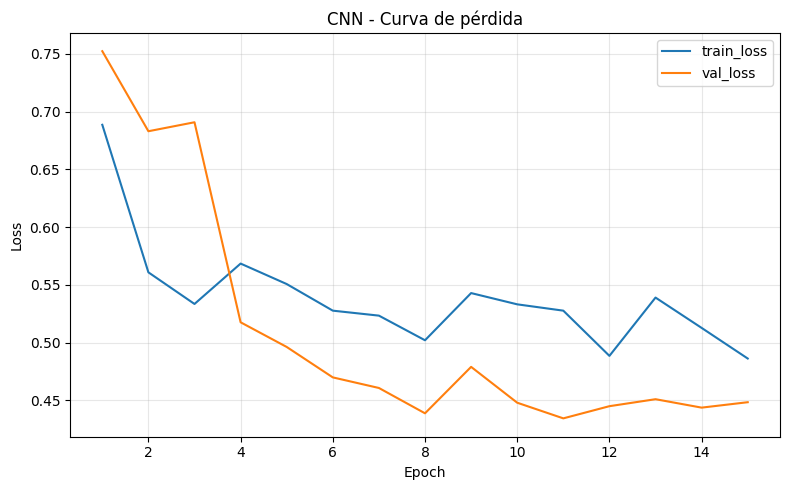

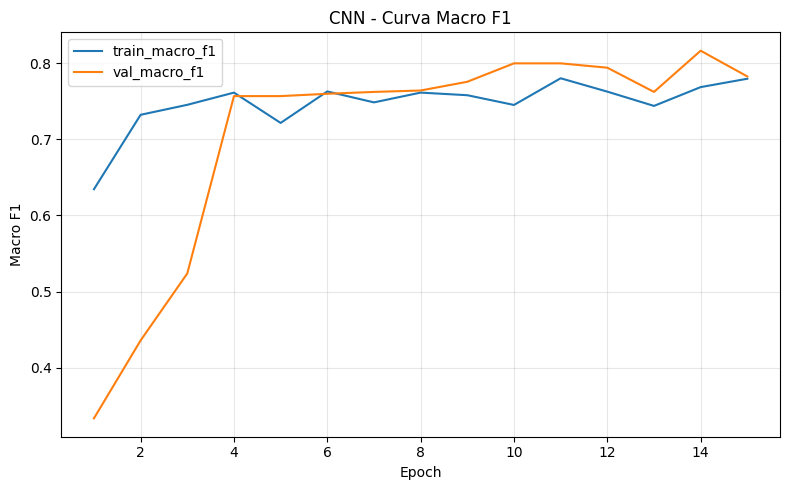

In [ ]:
# curvas para analizar sobreajuste/subajuste

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN - Curva de pérdida")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "cnn_loss_curve.png", dpi=160)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_macro_f1"], label="train_macro_f1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="val_macro_f1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("CNN - Curva Macro F1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "cnn_macro_f1_curve.png", dpi=160)
plt.show()


SimpleAstroCNN_test
{
  "model": "SimpleAstroCNN_test",
  "accuracy": 0.8,
  "balanced_accuracy": 0.8,
  "macro_precision": 0.8125,
  "macro_recall": 0.8,
  "macro_f1": 0.797979797979798
}
              precision    recall  f1-score   support

    estrella       0.88      0.70      0.78        30
     galaxia       0.75      0.90      0.82        30

    accuracy                           0.80        60
   macro avg       0.81      0.80      0.80        60
weighted avg       0.81      0.80      0.80        60



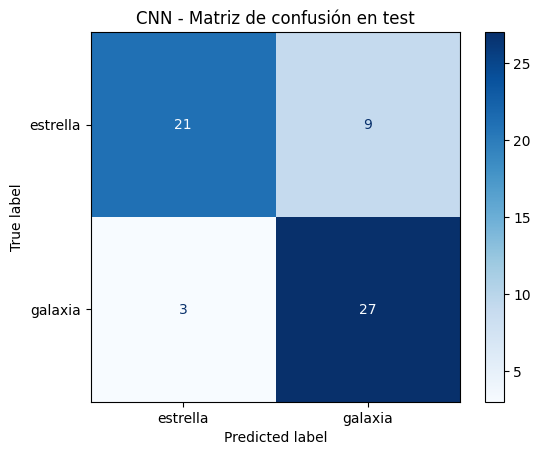

{'model': 'SimpleAstroCNN_test',
 'accuracy': 0.8,
 'balanced_accuracy': 0.8,
 'macro_precision': 0.8125,
 'macro_recall': 0.8,
 'macro_f1': 0.797979797979798}

In [ ]:
# Evaluación final en test

# Cargar mejor modelo
best_model = SimpleAstroCNN(num_classes=len(train_dataset.classes)).to(device)
best_model.load_state_dict(torch.load(best_model_path, map_location=device))

test_metrics = run_epoch(best_model, test_loader, criterion, optimizer=None)

class_names = test_dataset.classes
cnn_test_result = evaluate_predictions(
    np.array(test_metrics["y_true"]),
    np.array(test_metrics["y_pred"]),
    name="SimpleAstroCNN_test",
    labels=class_names,
)

# Guardar report completo
report_dict = classification_report(
    test_metrics["y_true"],
    test_metrics["y_pred"],
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

with open(ARTIFACTS_DIR / "cnn_classification_report.json", "w") as f:
    json.dump(report_dict, f, indent=2)

with open(ARTIFACTS_DIR / "cnn_test_metrics.json", "w") as f:
    json.dump(cnn_test_result, f, indent=2)

cm = confusion_matrix(test_metrics["y_true"], test_metrics["y_pred"])
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("CNN - Matriz de confusión en test")
plt.savefig(ARTIFACTS_DIR / "cnn_confusion_matrix.png", dpi=160)
plt.show()

cnn_test_result

## 7. Resumen del Avance 3

Esta sección genera un resumen automático con los resultados principales y deja una guía para responder las preguntas solicitadas.


In [ ]:
# resultados

results = []

# Dummy
results.extend(dummy_results)

# Random Forest
results.append(rf_val_metrics)
results.append(rf_test_metrics)

# CNN
results.append(cnn_test_result)

results_df = pd.DataFrame(results)
results_df.to_csv(ARTIFACTS_DIR / "all_baseline_results.csv", index=False)

display(results_df.sort_values("macro_f1", ascending=False))


def make_json_safe(obj):
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}

    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]

    if isinstance(obj, tuple):
        return [make_json_safe(v) for v in obj]

    if isinstance(obj, Path):
        return str(obj)

    if isinstance(obj, (np.integer,)):
        return int(obj)

    if isinstance(obj, (np.floating,)):
        return float(obj)

    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()

    return obj


class_distribution = (
    split_manifest
    .groupby(["split", "label"])
    .size()
    .reset_index(name="count")
)

class_distribution_nested = {}

for _, row in class_distribution.iterrows():
    split = str(row["split"])
    label = str(row["label"])
    count = int(row["count"])

    if split not in class_distribution_nested:
        class_distribution_nested[split] = {}

    class_distribution_nested[split][label] = count


summary = {
    "class_distribution": class_distribution_nested,
    "dummy_results": dummy_results,
    "random_forest_val": rf_val_metrics,
    "random_forest_test": rf_test_metrics,
    "cnn_test": cnn_test_result,
    "feature_importance_top10": importances.head(10).to_dict(orient="records"),
    "best_cnn_model_path": str(best_model_path),
    "artifacts_dir": str(ARTIFACTS_DIR),
    "avance3_interpretation": {
        "problem_type": "clasificación binaria estrella vs galaxia",
        "primary_metric": "macro_f1",
        "minimum_expected_performance": "superar DummyClassifier y obtener macro_f1 >= 0.65 como umbral inicial de viabilidad",
        "baseline_models": [
            "DummyClassifier_most_frequent",
            "DummyClassifier_stratified",
            "RandomForest_features",
            "SimpleAstroCNN"
        ]
    }
}

summary = make_json_safe(summary)

with open(ARTIFACTS_DIR / "avance3_baseline_summary.json", "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f"Artefactos guardados en: {ARTIFACTS_DIR}")

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1
4,SimpleAstroCNN_test,0.800000,0.800000,0.812500,0.800000,0.797980
3,RandomForest_features_test,0.766667,0.766667,0.777778,0.766667,0.764310
2,RandomForest_features_val,0.700000,0.700000,0.700000,0.700000,0.700000
1,DummyClassifier_stratified,0.466667,0.466667,0.466518,0.466667,0.466073
0,DummyClassifier_most_frequent,0.500000,0.500000,0.250000,0.500000,0.333333


Artefactos guardados en: /content/drive/MyDrive/MNA/PI/avance3/artifacts


## 8. Conclusiones

**Algoritmo baseline.**  
Se aplicaron tres procesos para tomarlos como referencias.

<br>

Primero:
  - Clase mayoritaria
  - Predicción aleatoria estratificada

Segundo:
  - Random Forest
    - Entrenado con características simples extraídas de las imágenes, como intensidad, concentración, proporción de píxeles brillantes y asimetría.

Tercero:
  - CNN simple entrenada directamente sobre los tiles astronómicos
    - Esta estrategia permite comparar una solución básica, una solución clásica interpretable y una solución visual basada en aprendizaje profundo.

<br>

**Importancia de características.**  
El Random Forest permite estimar la importancia relativa de las características mediante `feature_importances_` y, opcionalmente, `permutation importance`.

Esto permite identificar si variables como concentración, brillo máximo, asimetría o proporción de píxeles brillantes aportan información para distinguir estrellas y galaxias

<br>

**Subajuste / sobreajuste.**  
El ajuste del modelo se evalúa con las curvas de pérdida y macro F1 en entrenamiento y validación.

Si el desempeño en entrenamiento es alto pero el de validación se estanca o disminuye, se considera posible sobreajuste.

Si ambos desempeños son bajos, se considera posible subajuste.

<br>

**Métrica principal.**  
La métrica principal propuesta es macro F1-score, porque el objetivo es evaluar el desempeño promedio entre estrella y galaxia sin favorecer a la clase mayoritaria.

También se reportan balanced accuracy, precision, recall, accuracy y matriz de confusión.

<br>

**Desempeño**  
Los resultados del baseline muestran que el problema de clasificación estrella vs galaxia es viable.

Los clasificadores "dummy" obtuvieron un desempeño bajo, con macro F1-score de 0.33 para la clase mayoritaria y 0.46 para el clasificador aleatorio estratificado.

El Random Forest basado en características alcanzó un macro F1-score de 0.76 en test.

La CNN obtuvo el mejor resultado con accuracy de 0.80, balanced accuracy de 0.80 y macro F1-score de 0.798.

Estos resultados indican que las imágenes contienen información discriminativa suficiente para superar el azar y la clase mayoritaria.

Debido a esto se puede concluir que la CNN puede utilizarse como baseline visual inicial, mientras que el Random Forest funciona como baseline interpretable para analizar la importancia de características.

Estos resultados deben considerarse preliminares y deberán validarse con un dataset más amplio, control de calidad de tiles, revisión de matriz de confusión y particiones que reduzcan el riesgo de fuga de información.